# t-SNE with DBSCAN Clustering and Evaluation

This notebook identifies subpopulations of sepsis patients using t-SNE dimensionality reduction followed by DBSCAN Clustering.

- Load the prepared and min-max scaled clustering dataset
- Reduce the high-dimensional patient features to two-dimensions using t-SNE
- Examine the $50$-nearest-neighbor distance curve
- Apply DBSCAN using $\text{MinPts} = 50$
- Evaluate the clusters using internal clustering metrics
- Compare clinical outcomes across the identified clusters
- Evaluate ICU survival using Kaplan-Meier analysis
- Examine the clincal features that distinguish the patient subpopulations

## Setup

### Import Required Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Matplotlib controls figures, labels and saving plots
import matplotlib.pyplot as plt

# Seaborn provides cleaner statistical visualizations
import seaborn as sns

# t-SNE reduces the high-dimensional patient data to two-dimensions
from sklearn.manifold import TSNE

# Used to calculate the 50-nearest-neighbor distances for DBSCAN epsilon selection
from sklearn.neighbors import NearestNeighbors

# Density-based clustering algorithm used
from sklearn.cluster import DBSCAN

# Internal clustering evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Survival analysis tools
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

### Set Plot Style

In [2]:
# Apply a simple seaborn style to all plots
sns.set_theme(style = "whitegrid")

### Set Project Folder Paths

In [3]:
ROOT = Path.cwd().parents[1]

# Original eICU CSV Files
DATA_DIR = ROOT / "data"

# Results produced by the previous dataset preparation notebook
PREP_RESULTS_DIR = ROOT / "results" / "module_2" / "dataset_creation"

# Results produced by this notebook
RESULTS_DIR = ROOT / "results" / "module_2" / "tsne_dbscan"

# Plots produced by this notebook
PLOTS_DIR = ROOT / "plots" / "module_2" / "tsne_dbscan"

# Create the output folders if they do not already exist
RESULTS_DIR.mkdir(parents = True, exist_ok = True)
PLOTS_DIR.mkdir(parents = True, exist_ok = True)

print(f"Root Folder : {ROOT.resolve()}")
print(f"Data Folder : {DATA_DIR.resolve()}")
print(f"Results Folder : {RESULTS_DIR.resolve()}")
print(f"Plots Folder : {PLOTS_DIR.resolve()}")

Root Folder : C:\Users\samsa\Documents\ICU Clustering
Data Folder : C:\Users\samsa\Documents\ICU Clustering\data
Results Folder : C:\Users\samsa\Documents\ICU Clustering\results\module_2\tsne_dbscan
Plots Folder : C:\Users\samsa\Documents\ICU Clustering\plots\module_2\tsne_dbscan


### Load the Prepared Clustering Dataset

In [4]:
CLUSTERING_DATA_PATH = PREP_RESULTS_DIR / "feature_data_scaled.csv"

# Load the final patient-level clustering dataset
clustering_df = pd.read_csv(CLUSTERING_DATA_PATH)

print(f"Dataset Shape : {clustering_df.shape}")

clustering_df.head()

Dataset Shape : (7648, 81)


,patientunitstayid,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,1.0,0.271546,0.077035,0.055777,0.270588,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,210208,0.472222,0.0,0.267434,0.058982,0.039841,0.476471,0.016535,0.321429,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,1.0,0.254770,0.061000,0.183267,0.400000,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,1.0,0.275658,0.075577,0.039841,0.700000,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,166175,0.583333,0.0,0.304934,0.100695,0.023904,0.535294,0.043701,0.428571,0.414634,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Verify the Prepared Clustering Dataset

In [5]:
# Unique eICU ICU-stay identifier
ID_COL = "patientunitstayid"

# Every column except the patient identifier is treated as a clustering feature
feature_cols = [column for column in clustering_df.columns if column != ID_COL]

# X contains only the variables that will be given to t-SNE
X = clustering_df[feature_cols].copy()

print(f"Patients : {len(clustering_df)}")
print(f"Clustering Feature : {len(feature_cols)}")

# There should be one row per patient/ICU stay
print(f"Duplicate Patient IDs : {clustering_df[ID_COL].duplicated().sum()}")

# t-SNE required complete finite numerical values
print(f"Missing Values : {X.isna().sum().sum()}")

print(f"Infinite Values : {np.isinf(X.to_numpy()).sum()}")

# These values should be between 0 and 1
print(
    "Minimum feature value:",
    X.min().min()
)

print(
    "Maximum feature value:",
    X.max().max()
)

Patients : 7648
Clustering Feature : 80
Duplicate Patient IDs : 0
Missing Values : 0
Infinite Values : 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


## t-SNE Dimensionality Reduction

### Set t-SNE Parameters

In [6]:
# Higher dimensions are being converted to Two-Dimensions
TSNE_COMPONENTS = 2

# Standard and Starting Reproducible Choice
TSNE_PERPLEXITY = 30

# Fixed seed males our t-SNE result reproducible
RANDOM_STATE = 42

print("t-SNE dimensions:", TSNE_COMPONENTS)
print("t-SNE perplexity:", TSNE_PERPLEXITY)
print("Random state:", RANDOM_STATE)

t-SNE dimensions: 2
t-SNE perplexity: 30
Random state: 42


### Create the Two-Dimensional t-SNE Representation

In [7]:
# Create the t-SNE model
tsne = TSNE(
    n_components=TSNE_COMPONENTS,    # Reduce data to two dimensions
    perplexity = TSNE_PERPLEXITY,    # Controls the effective neighborhood size
    metric = "euclidean",            # Distance metric used
    init = "pca",                    # Stable initialization for reproducibility
    learning_rate = "auto",          # Let scikit-learn choose an appropriate rate
    max_iter = 1000,                 # Number of optimization iterations
    random_state = RANDOM_STATE      # Reproducible result
)

# Learn the two-dimensional representation of all patients
tsne_embedding = tsne.fit_transform(X)

print(f"Original Feature Matrix Shape : {X.shape}")
print(f"t-SNE Embedding Shape : {tsne_embedding.shape}")

Original Feature Matrix Shape : (7648, 80)
t-SNE Embedding Shape : (7648, 2)


### Create the t-SNE Results Table

In [8]:
# Store the patient identifier together with the two t-SNE coordinates
tsne_results = pd.DataFrame(
    {
        ID_COL : clustering_df[ID_COL].values,
        "tsne_1" : tsne_embedding[:,0],
        "tsne_2" : tsne_embedding[:,1]
    }
)

print("t-SNE Results Shape : {tsne_results.shape}")

tsne_results.head()

t-SNE Results Shape : {tsne_results.shape}


,patientunitstayid,tsne_1,tsne_2
0,151900,-69.437340,2.642728
1,210208,-58.957081,14.864347
2,179269,21.402903,21.252129
3,172764,12.093176,20.938839
4,166175,26.010063,-36.307499


## Visualize the t-SNE Representation

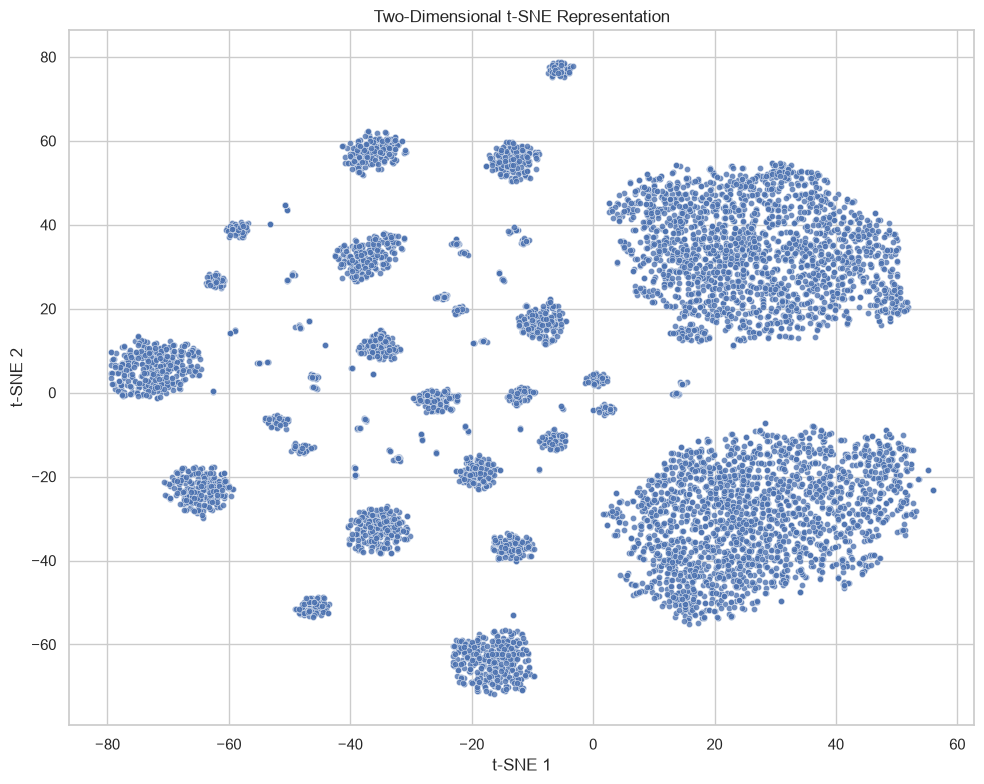

In [9]:
plt.figure(figsize=(10,8))

# The plot only shows the patient distribution in the t-SNE space
sns.scatterplot(
    data = tsne_results,
    x = 'tsne_1',
    y = "tsne_2",
    s = 20,
    alpha = 0.8,
)

plt.title("Two-Dimensional t-SNE Representation")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()

# Save a high-resolution copy for the report
plt.savefig(
    PLOTS_DIR / "tsne_representation.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

## DBSCAN Parameter Selection

### Calculate the $50$-Nearest-Neighbor Distances

In [10]:
# Number of neighboring observations required by DBSCAN
MIN_SAMPLES = 50

# Find the 50 nearest patient around every patient
neighbors = NearestNeighbors(
    n_neighbors = MIN_SAMPLES,
    metric = "euclidean"
)

# Fit the nearest-neighbor model on the two-dimensional t-SNE coordinates
neighbors.fit(tsne_embedding)

# distances contains the distance to each of the 50 nearest neighbors
distances,_ = neighbors.kneighbors(tsne_embedding)

# The last column is the distance to the 50th nearest neighbor
# Sorting these values creates the k-distance curve
k_distances = np.sort(distances[:,-1])

print(f"Number of k-distance values : {len(k_distances)}")
print(f"Minimum distance : {round(k_distances.min(),4)}")
print(f"Maximum distance : {round(k_distances.max(),4)}")

Number of k-distance values : 7648
Minimum distance : 1.629
Maximum distance : 11.963


### Plot the 50-Nearest-Neighbor Distance Curve

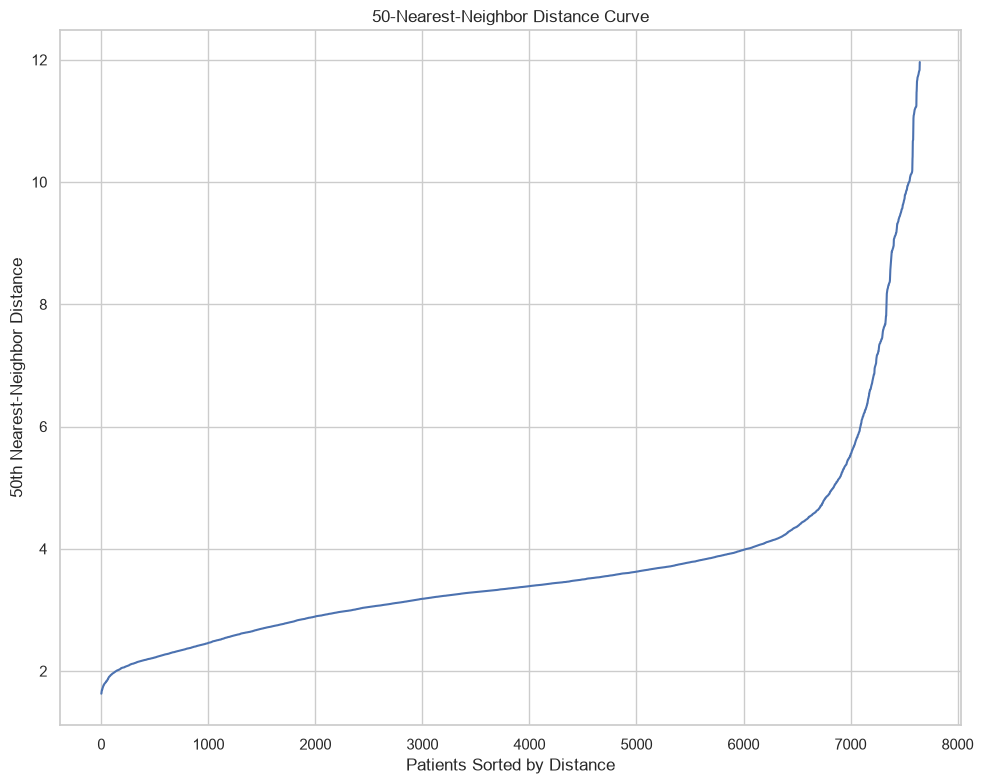

In [11]:
plt.figure(figsize=(10,8))

# Plot the sorted distance to each patient's 50th nearest neighbor
plt.plot(k_distances)
plt.title("50-Nearest-Neighbor Distance Curve")
plt.xlabel("Patients Sorted by Distance")
plt.ylabel("50th Nearest-Neighbor Distance")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_k_distance_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Examine the Upper k-Distance Values

In [12]:
# These percentiles help us understand where the upper portion of the k-distance curve begins to increase
k_distance_summary = pd.Series(k_distances).describe(
    percentiles = [
        0.90,
        0.95,
        0.97,
        0.98,
        0.99
    ]
)

k_distance_summary

count    7648.000000
mean        3.692829
std         1.599225
min         1.628963
50%         3.353098
90%         5.121043
95%         7.289230
97%         9.122497
98%         9.657263
99%        10.145800
max        11.962956
dtype: float64

## Compare a Supported Epsilon Range

In [13]:
# Test a small range around the values.
eps_values = [
    3.0,
    3.5,
    4.0,
    4.5,
    5.0,
    5.5,
    6.0,
    6.5,
    7.0
]

eps_results = []

for eps in eps_values :
    # Fit DBSCAN using the current epsilon value
    model = DBSCAN(
        eps = eps,
        min_samples = MIN_SAMPLES,
        metric = "euclidean"
    )
    labels = model.fit_predict(tsne_embedding)

    # DBSCAN labels noise/outliers as -1
    n_clusters_temp = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    n_outliers_temp = np.sum(labels == -1)

    outlier_percent_temp = (
        n_outliers_temp / len(labels)
    ) * 100

    eps_results.append({
        "epsilon": eps,
        "clusters": n_clusters_temp,
        "outliers": n_outliers_temp,
        "outlier_percentage": outlier_percent_temp
    })

# Convert the parameter comparison into an easy-to-read table
eps_comparison = pd.DataFrame(eps_results)

eps_comparison.round(2)

,epsilon,clusters,outliers,outlier_percentage
0,3.0,29,3318,43.38
1,3.5,28,1056,13.81
2,4.0,23,576,7.53
3,4.5,23,471,6.16
4,5.0,23,445,5.82
5,5.5,23,352,4.60
6,6.0,23,346,4.52
7,6.5,22,327,4.28
8,7.0,21,243,3.18


## t-SNE DBSCAN Clustering

### Set the Final DBSCAN Parameters

In [14]:
EPS = 4.0

print("Final epsilon:", EPS)
print("Final min_samples:", MIN_SAMPLES)

Final epsilon: 4.0
Final min_samples: 50


## Apply DBSCAN to the t-SNE Representation

In [15]:
# Create the DBSCAN Clustering Model
dbscan = DBSCAN(
    eps = EPS,                    # Maximum neighborhood radius
    min_samples = MIN_SAMPLES,    # Minimum dense neighborhood size
    metric = "euclidean"          # Same distance metric used throughout
)

# Assign every patient to a cluster
# A value of -1 means DBSCAN classified that patient as noise/outlier
cluster_labels = dbscan.fit_predict(tsne_embedding)

# Add the cluster assignments to the t-SNE results table
tsne_results["cluster"] = cluster_labels

tsne_results.head()

,patientunitstayid,tsne_1,tsne_2,cluster
0,151900,-69.437340,2.642728,0
1,210208,-58.957081,14.864347,-1
2,179269,21.402903,21.252129,1
3,172764,12.093176,20.938839,1
4,166175,26.010063,-36.307499,2


### Summarize the DBSCAN Results

In [16]:
# The -1 noise group is not counted as a cluster
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

# Count DBSCAN noise observations
n_outliers = np.sum(cluster_labels == -1)

# Calculate the percentage of patients classified as noise
outlier_percentage = (
    n_outliers / len(cluster_labels)
) * 100

print(f"DBSCAN epsilon : {EPS}")
print(f"DBSCAN min_samples : {MIN_SAMPLES}")
print(f"Number of Clusters : {n_clusters}")
print(f"Number of Outliers : {n_outliers}")
print(f"Outlier Percentage : {round(outlier_percentage, 2)}%")

DBSCAN epsilon : 4.0
DBSCAN min_samples : 50
Number of Clusters : 23
Number of Outliers : 576
Outlier Percentage : 7.53%


### Check the Number of Patients in Each Cluster

In [17]:
# Count how many patients were assigned to every DBSCAN cluster
# Cluster -1 represents DBSCAN outliers
cluster_distribution = (
    tsne_results["cluster"]
    .value_counts()
    .sort_index()
    .rename("patients")
    .to_frame()
)

cluster_distribution

,patients
cluster,
-1,576
0,360
1,2045
2,2041
3,345
4,87
5,173
6,227
7,170


## Visualize the t-SNE DBSCAN Clusters

In [18]:
# Get all discover cluster labels
unique_clusters = sorted(
    tsne_results["cluster"].unique()    
)

# Separate actual clusters from DBSCAN noise
normal_clusters = [
    cluster
    for cluster in unique_clusters
    if cluster != -1
]

# Generate one visual color per actual cluster
cluster_colors = sns.color_palette(
    "dark",
    len(normal_clusters)
)

cluster_palette = dict(
    zip(normal_clusters, cluster_colors)
)

# Display outliers in gray so they are easy to distinguish
cluster_palette[-1] = "lightgray"

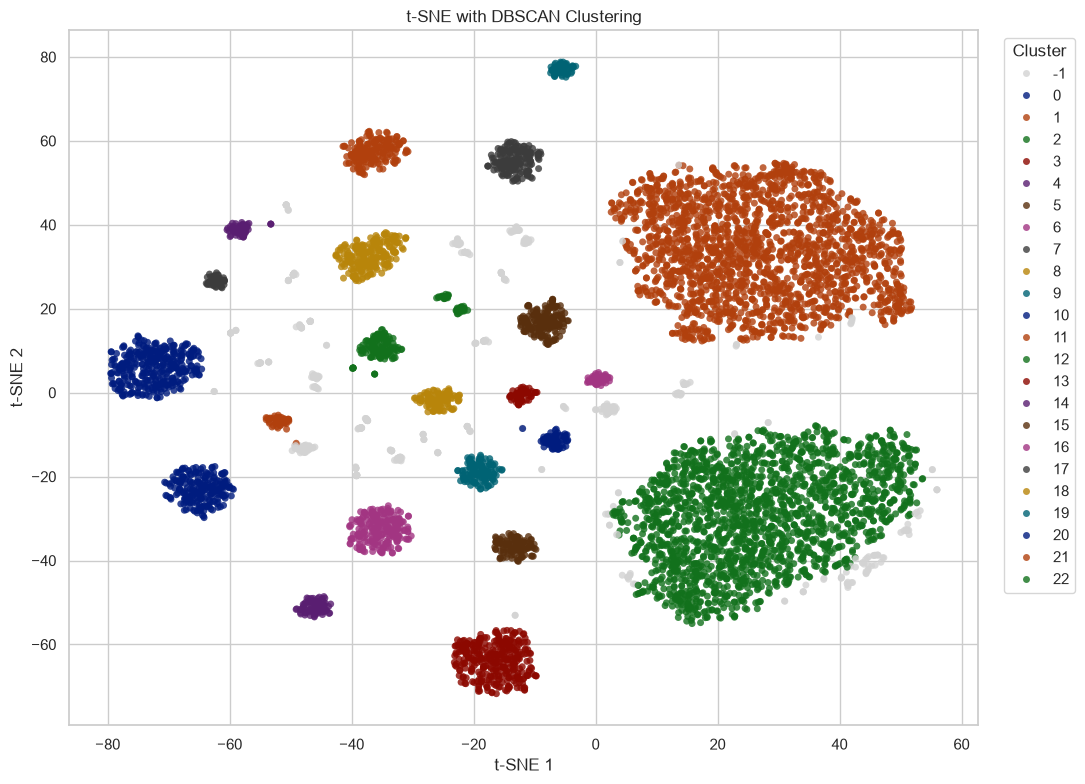

In [19]:
plt.figure(figsize=(11, 8))

# Plot patients using their DBSCAN cluster assignment as the color
sns.scatterplot(
    data=tsne_results,
    x="tsne_1",
    y="tsne_2",
    hue="cluster",
    palette=cluster_palette,
    s=25,
    alpha=0.8,
    linewidth=0
)

plt.title("t-SNE with DBSCAN Clustering")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Move the large cluster legend outside the plotting area
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Internal Cluster Evaluation

### Remove DBSCAN Outliers for Evaluation

In [20]:
# DBSCAN noise should not be treated as another clinical cluster
evaluation_mask = (
    tsne_results["cluster"] != -1
)

# Use the two t-SNE coordinates for internal cluster evaluation
X_evaluation = tsne_results.loc[
    evaluation_mask,
    ["tsne_1", "tsne_2"]
]

# Keep the corresponding DBSCAN cluster labels
labels_evaluation = tsne_results.loc[
    evaluation_mask,
    "cluster"
]

print("Patients used for evaluation:", len(X_evaluation))
print("Clusters evaluated:", labels_evaluation.nunique())

Patients used for evaluation: 7072
Clusters evaluated: 23


### Calculate Internal Cluster Metrics

In [21]:
# Measures cohesion within clusters and separation between clusters.
# Higher values are better.
silhouette = silhouette_score(
    X_evaluation,
    labels_evaluation
)

# Measures how similar each cluster is to its most similar neighboring cluster.
# Lower values are better.
dbi = davies_bouldin_score(
    X_evaluation,
    labels_evaluation
)

# Compares between-cluster separation with within-cluster variation.
# Higher values are better.
chi = calinski_harabasz_score(
    X_evaluation,
    labels_evaluation
)

print("Silhouette Score:", round(silhouette, 4))
print("Davies-Bouldin Index:", round(dbi, 4))
print("Calinski-Harabasz Index:", round(chi, 2))

Silhouette Score: 0.5605
Davies-Bouldin Index: 0.336
Calinski-Harabasz Index: 4696.96


### Create the Internal Evaluation Summary

In [22]:
evaluation_summary = pd.DataFrame({
    "metric": [
        "Number of clusters",
        "Number of outliers",
        "Outlier percentage",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],
    "value": [
        n_clusters,
        n_outliers,
        outlier_percentage,
        silhouette,
        dbi,
        chi
    ]
})

evaluation_summary.round(4)

,metric,value
0,Number of clusters,23.0000
1,Number of outliers,576.0000
2,Outlier percentage,7.5314
3,Silhouette Score,0.5605
4,Davies-Bouldin Index,0.3360
5,Calinski-Harabasz Index,4696.9648


## Clinical Outcome Evaluation

### Load Required Clinical Outcome Data

In [23]:
# Load only the patient columns needed for clinical evaluation
patient = pd.read_csv(
    DATA_DIR / "patient.csv",
    usecols=[
        "patientunitstayid",
        "age",
        "unitdischargeoffset",
        "hospitaldischargeoffset",
        "unitdischargestatus",
        "hospitaldischargestatus"
    ]
)

# APACHE IVa is used as a measure of illness severity
apache = pd.read_csv(
    DATA_DIR / "apachePatientResult.csv",
    usecols=[
        "patientunitstayid",
        "apacheversion",
        "apachescore"
    ]
)

print("Patient table shape:", patient.shape)
print("APACHE table shape:", apache.shape)

Patient table shape: (200859, 6)
APACHE table shape: (297064, 3)


### Prepare Age and Length-of-Stay(LOS) Variables

In [24]:
# Work on a copy so that original patient table remains unchanged
outcomes = patient.copy()

# eICU records patients older than 89 using the text "> 89".
# Convert this to 90 so age can be used numerically.
outcomes["age"] = outcomes["age"].replace(
    "> 89",
    "90"
)

outcomes["age"] = pd.to_numeric(
    outcomes["age"],
    errors="coerce"
)

# eICU discharge offsets are stored in minutes.
# Divide by 1440 to convert minutes into days.
outcomes["icu_los_days"] = (
    outcomes["unitdischargeoffset"] / 1440
)

outcomes["hospital_los_days"] = (
    outcomes["hospitaldischargeoffset"] / 1440
)

outcomes[
    [
        "age",
        "icu_los_days",
        "hospital_los_days"
    ]
].describe()

,age,icu_los_days,hospital_los_days
count,200764.000000,200859.000000,200859.000000
mean,63.079456,2.679258,6.780328
std,17.178207,4.330865,10.368080
min,0.000000,-5.338194,-5.936806
25%,53.000000,0.818750,2.306944
50%,65.000000,1.573611,4.545139
75%,76.000000,2.971528,8.026389
max,90.000000,506.372222,1096.746528


### Create ICU and Hospital Mortality Indicators

In [25]:
# Convert ICU discharge status into a binary mortality variable:
# Alive = 0 and Expired = 1
outcomes["icu_mortality"] = (
    outcomes["unitdischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

# Create the same type of binary indicator for hospital mortality
outcomes["hospital_mortality"] = (
    outcomes["hospitaldischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

print("ICU mortality:")
print(
    outcomes["icu_mortality"]
    .value_counts(dropna=False)
)

print()

print("Hospital mortality:")
print(
    outcomes["hospital_mortality"]
    .value_counts(dropna=False)
)

ICU mortality:
icu_mortality
0.0    189918
1.0     10907
NaN        34
Name: count, dtype: int64

Hospital mortality:
hospital_mortality
0.0    181104
1.0     18004
NaN      1751
Name: count, dtype: int64


### Check Available APACHE Versions

In [26]:
# Verify how APACHE versions are written in the eICU table
apache["apacheversion"].value_counts(dropna = False)

apacheversion
IV     148532
IVa    148532
Name: count, dtype: int64

### Prepare APACHE IVa Scores

In [27]:
# Keep only APACHE IVa because this is the score used for clinical severity comparison
apache_iva = apache[
    apache["apacheversion"] == "IVa"
][
    [
        'patientunitstayid',
        'apachescore'
    ]
].copy()

# Keep one APACHE record per ICU stay
apache_iva = apache_iva.drop_duplicates(
    subset="patientunitstayid"
)

# Give the score a descriptive name
apache_iva = apache_iva.rename(
    columns={
        "apachescore": "apache_iva"
    }
)

print("Patients with APACHE IVa:", len(apache_iva))

apache_iva.head()

Patients with APACHE IVa: 148532


,patientunitstayid,apache_iva
1,141168,65
3,141194,70
4,141203,90
6,141208,17
8,141227,100


### Merge Clinical Outcomes with t-SNE Clusters

In [28]:
# Join the cluster assignments with patient outcomes and APACHE scores
# using patientunitstayid as the common identifier
clinical_results = (
    tsne_results
    .merge(
        outcomes,
        on=ID_COL,
        how="left"
    )
    .merge(
        apache_iva,
        on=ID_COL,
        how="left"
    )
)

print("Patients after clinical merge:", len(clinical_results))

clinical_results.head()

Patients after clinical merge: 7648


,patientunitstayid,tsne_1,tsne_2,cluster,age,hospitaldischargeoffset,hospitaldischargestatus,unitdischargeoffset,unitdischargestatus,icu_los_days,hospital_los_days,icu_mortality,hospital_mortality,apache_iva
0,151900,-69.437340,2.642728,0,66.0,6355,Alive,3460,Alive,2.402778,4.413194,0.0,0.0,68.0
1,210208,-58.957081,14.864347,-1,52.0,8352,Alive,5478,Alive,3.804167,5.800000,0.0,0.0,49.0
2,179269,21.402903,21.252129,1,82.0,24087,Alive,3655,Alive,2.538194,16.727083,0.0,0.0,117.0
3,172764,12.093176,20.938839,1,71.0,10974,Alive,2077,Alive,1.442361,7.620833,0.0,0.0,NaN
4,166175,26.010063,-36.307499,2,60.0,10037,Alive,1175,Alive,0.815972,6.970139,0.0,0.0,47.0


### Create the Cluster Clinical Outcome Summary

In [29]:
# Exclude DBSCAN noise from clinical cluster interpretation
cluster_clinical = clinical_results[
    clinical_results["cluster"] != -1
].copy()

# Calculate one clinical summary row for every t-SNE cluster
clinical_summary = (
    cluster_clinical
    .groupby("cluster")
    .agg(
        patients=(ID_COL, "size"),
        mean_age=("age", "mean"),
        mean_apache_iva=("apache_iva", "mean"),
        mean_icu_los=("icu_los_days", "mean"),
        mean_hospital_los=("hospital_los_days", "mean"),
        icu_mortality=("icu_mortality", "mean"),
        hospital_mortality=("hospital_mortality", "mean")
    )
    .reset_index()
)

# Calculate what percentage of clustered patients belong to each group
clinical_summary["patient_percentage"] = (
    clinical_summary["patients"]
    / clinical_summary["patients"].sum()
    * 100
)

# Mortality means are proportions such as 0.20.
# Multiply by 100 so the table displays percentages.
clinical_summary["icu_mortality"] *= 100
clinical_summary["hospital_mortality"] *= 100

# Arrange columns in an easy-to-read order
clinical_summary = clinical_summary[
    [
        "cluster",
        "patients",
        "patient_percentage",
        "mean_age",
        "mean_apache_iva",
        "mean_icu_los",
        "mean_hospital_los",
        "icu_mortality",
        "hospital_mortality"
    ]
]

clinical_summary.round(2)

,cluster,patients,patient_percentage,mean_age,mean_apache_iva,mean_icu_los,mean_hospital_los,icu_mortality,hospital_mortality
0,0,360,5.09,67.24,75.53,3.95,9.16,14.44,19.83
1,1,2045,28.92,66.48,73.13,3.68,8.34,12.96,19.21
2,2,2041,28.86,66.74,73.43,3.98,8.72,12.59,18.97
3,3,345,4.88,67.41,76.00,4.18,10.59,15.07,19.53
4,4,87,1.23,64.51,73.37,4.65,10.92,14.94,19.54
5,5,173,2.45,61.27,79.81,3.95,9.83,12.14,21.43
6,6,227,3.21,67.21,73.22,4.13,8.67,10.57,21.15
7,7,170,2.40,59.53,70.68,4.29,10.47,10.00,19.41
8,8,223,3.15,66.32,72.37,3.95,8.67,11.21,17.94
9,9,65,0.92,65.22,75.70,9.08,13.86,18.46,19.05


### Visualize Hospitality Mortality Across Clusters

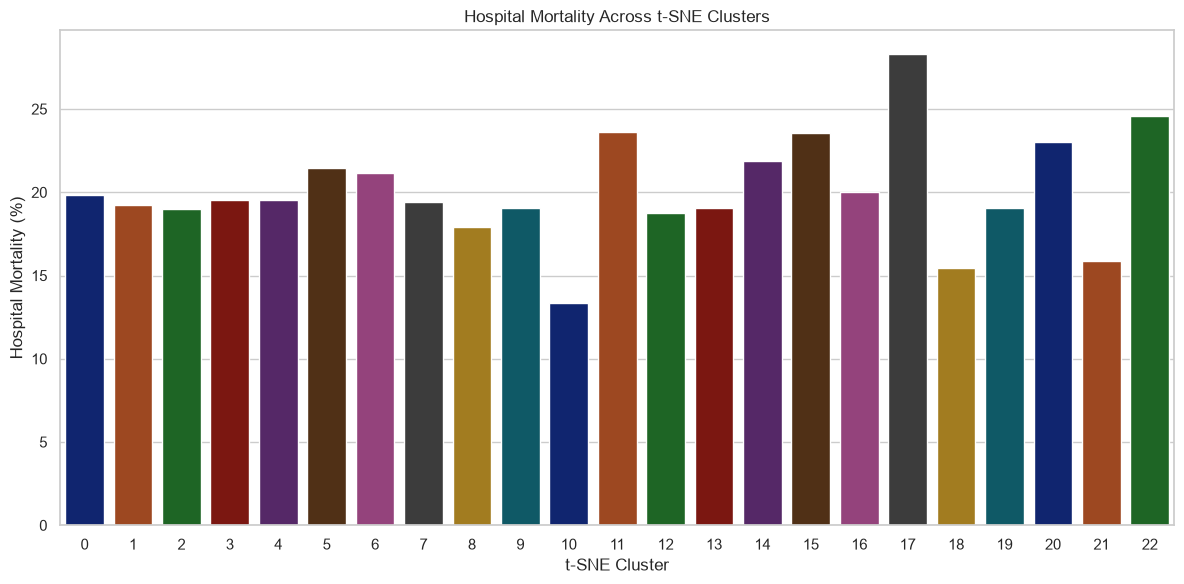

In [30]:
plt.figure(figsize=(12, 6))

# Compare hospital mortality percentages across the discovered clusters
sns.barplot(
    data=clinical_summary,
    x="cluster",
    y="hospital_mortality",
    errorbar=None,
    hue = "cluster",
    palette = "dark",
    legend = False
)

plt.title("Hospital Mortality Across t-SNE Clusters")
plt.xlabel("t-SNE Cluster")
plt.ylabel("Hospital Mortality (%)")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_hospital_mortality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Visualize APACHE IVa Across Clusters

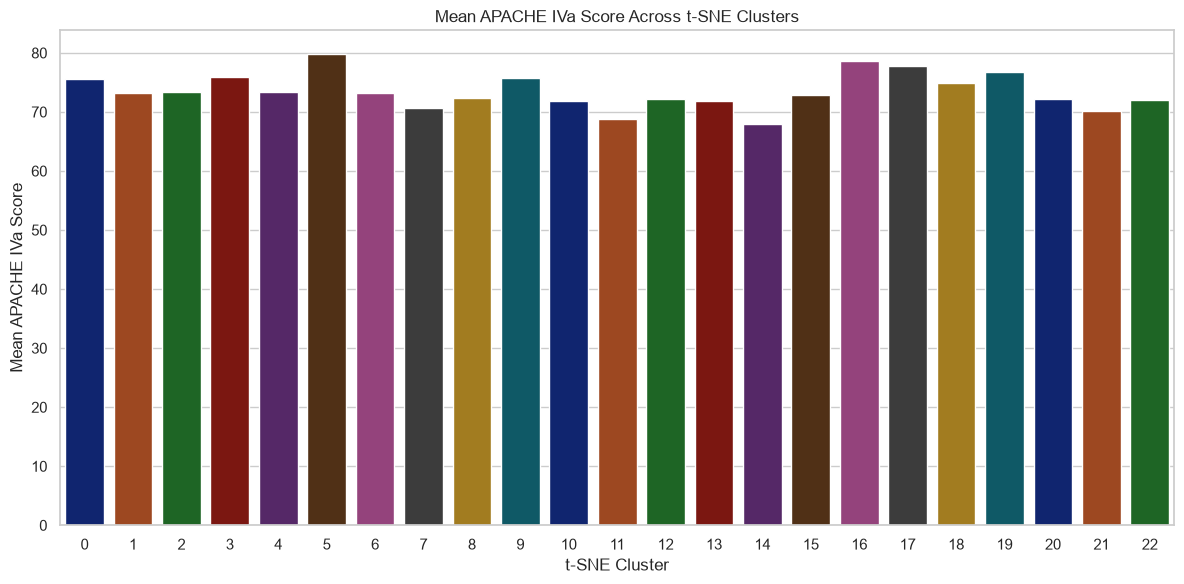

In [31]:
plt.figure(figsize=(12, 6))

# Compare average illness severity across clusters
sns.barplot(
    data=clinical_summary,
    x="cluster",
    y="mean_apache_iva",
    errorbar=None,
    hue = "cluster",
    palette = "dark",
    legend = False
)

plt.title("Mean APACHE IVa Score Across t-SNE Clusters")
plt.xlabel("t-SNE Cluster")
plt.ylabel("Mean APACHE IVa Score")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_apache_iva.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ICU Survival Evaluation

### Preparation ICU Survival Data

In [32]:
# Keep only actual clusters with valid ICU length of stay
# and valid mortality status
survival_data = clinical_results[
    (clinical_results["cluster"] != -1)
    & clinical_results["icu_los_days"].notna()
    & clinical_results["icu_mortality"].notna()
    & (clinical_results["icu_los_days"] >= 0)
].copy()

print("Patients:", len(survival_data))

print(
    "Number of clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(survival_data["icu_mortality"].sum())
)

print(
    "Minimum ICU LOS:",
    survival_data["icu_los_days"].min()
)

print(
    "Maximum ICU LOS:",
    survival_data["icu_los_days"].max()
)

Patients: 7072
Number of clusters: 23
ICU deaths: 908
Minimum ICU LOS: 0.0
Maximum ICU LOS: 246.90416666666667


### Plot Kaplan-Meier ICU Survival Curves

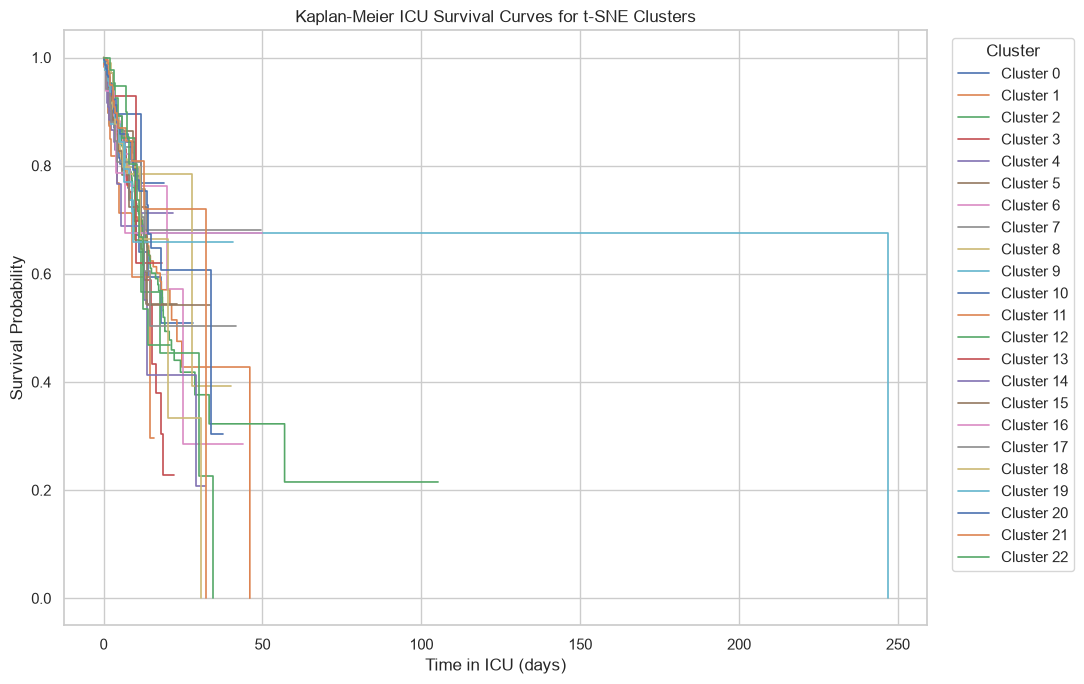

In [33]:
# KaplanMeierFitter estimates the survival probability over time
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(11, 7))

# Fit one survival curve for each t-SNE cluster
for cluster in sorted(
    survival_data["cluster"].unique()
):

    cluster_data = survival_data[
        survival_data["cluster"] == cluster
    ]

    kmf.fit(
        durations=cluster_data["icu_los_days"],
        event_observed=cluster_data["icu_mortality"],
        label=f"Cluster {cluster}"
    )

    # Confidence intervals are hidden to keep a 20+ cluster figure readable
    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        linewidth=1.2
    )

ax.set_title(
    "Kaplan-Meier ICU Survival Curves for t-SNE Clusters"
)

ax.set_xlabel("Time in ICU (days)")
ax.set_ylabel("Survival Probability")

# Place the large cluster legend outside the main plotting area
ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_kaplan_meier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Perform the Global Log-Rank Test

In [34]:
# Test the null hypothesis that all cluster survival curves are the same
logrank_result = multivariate_logrank_test(
    survival_data["icu_los_days"],
    survival_data["cluster"],
    survival_data["icu_mortality"]
)

print("Patients:", len(survival_data))

print(
    "Number of clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(survival_data["icu_mortality"].sum())
)

print(
    "Log-rank test statistic:",
    round(logrank_result.test_statistic, 4)
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

Patients: 7072
Number of clusters: 23
ICU deaths: 908
Log-rank test statistic: 22.4436
Log-rank p-value: 0.4336937225020905


## Clinical Interpretation

### Add Cluster Lables to the Clustering Features

In [35]:
# Copy the original clustering features
cluster_features = clustering_df.copy()

# Add the DBSCAN cluster assignment for each patient
cluster_features["cluster"] = (
    tsne_results["cluster"].to_numpy()
)

# Remove DBSCAN outliers because they do not represent a defined subgroup
cluster_features = cluster_features[
    cluster_features["cluster"] != -1
].copy()

print(
    "Patients used for clinical profiling:",
    len(cluster_features)
)

print(
    "Clusters profiled:",
    cluster_features["cluster"].nunique()
)

Patients used for clinical profiling: 7072
Clusters profiled: 23


### Standardize Features for Clinical Interpretation

In [36]:
# Calculate the overall cohort mean for each feature
feature_mean = X.mean()

# Calculate the overall cohort standard deviation.
# Replace zero values to avoid division-by-zero errors.
feature_std = X.std().replace(
    0,
    np.nan
)

# Convert each feature into a standardized value:
# 0 = cohort average
# positive = above cohort average
# negative = below cohort average
standardized_features = (
    X - feature_mean
) / feature_std

# Add DBSCAN cluster labels
standardized_features["cluster"] = (
    tsne_results["cluster"].to_numpy()
)

# Remove DBSCAN outliers
standardized_features = standardized_features[
    standardized_features["cluster"] != -1
]

standardized_features.head()

,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,cluster
0,0.043316,1.014687,-0.232191,0.123306,-0.744668,-1.132370,-0.684715,-0.140295,0.387933,-0.312693,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,0
2,1.037584,1.014687,-0.962713,-0.349726,0.613290,-0.099983,-0.812008,1.563175,-0.154015,0.805407,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,1
3,0.354024,1.014687,-0.053141,0.080303,-0.914413,2.293277,0.351810,2.201976,-1.057262,-0.452455,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,1
4,-0.329535,-0.985397,1.221691,0.821277,-1.084158,0.979330,-0.339207,0.924374,-0.334664,-1.291030,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,2
5,-2.131645,-0.985397,1.586952,1.049523,-0.405179,0.791624,-0.766546,-0.992029,2.194428,-0.452455,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,3


### Mean Feature Profiles for Each Cluster

In [37]:
# Calculate the average standardized value of every feature
# within each discovered patient cluster
cluster_profiles = (
    standardized_features
    .groupby("cluster")
    .mean()
)

print("Number of clusters:", cluster_profiles.shape[0])
print("Number of features:", cluster_profiles.shape[1])

cluster_profiles.head()

Number of clusters: 23
Number of features: 80


,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.120475,1.014687,-0.474723,-0.107700,-0.017713,-0.148344,0.091100,-0.049798,-0.164453,0.077089,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
1,0.073277,1.014687,-0.506385,-0.191969,-0.107519,-0.098950,0.020396,0.053605,-0.021174,0.000799,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
2,0.089107,-0.985397,0.553321,0.230352,0.070132,0.183991,-0.004647,-0.034829,0.123128,-0.106370,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
3,0.131215,-0.985397,0.551591,0.293763,0.155102,0.153557,0.037018,-0.166834,-0.018921,-0.056664,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
4,-0.049540,-0.985397,0.668325,0.379765,0.045035,-0.028245,-0.068548,-0.179455,0.073769,-0.034774,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,-1.466164,-0.155241,5.936484


### Identify the Most Distinguishing Features

In [38]:
# A feature that varies strongly between clusters is more useful
# for explaining what makes the clusters different.
feature_variation = (
    cluster_profiles
    .std(axis=0)
    .sort_values(ascending=False)
)

# Keep only the 15 most variable features so the heatmap remains readable
top_profile_features = (
    feature_variation
    .head(15)
    .index
)

print("Top 15 distinguishing features:")

for feature in top_profile_features:
    print(feature)

Top 15 distinguishing features:
ethnicity_Asian
unittype_Neuro ICU
ethnicity_Native American
unittype_SICU
ethnicity_African American
ethnicity_Hispanic
ethnicity_Other/Unknown
unittype_Cardiac ICU
ethnicity_Caucasian
unittype_CCU-CTICU
unittype_MICU
unittype_Med-Surg ICU
gender
admissionheight
min_creatinine


### Visualize the Clinical Feature Profiles

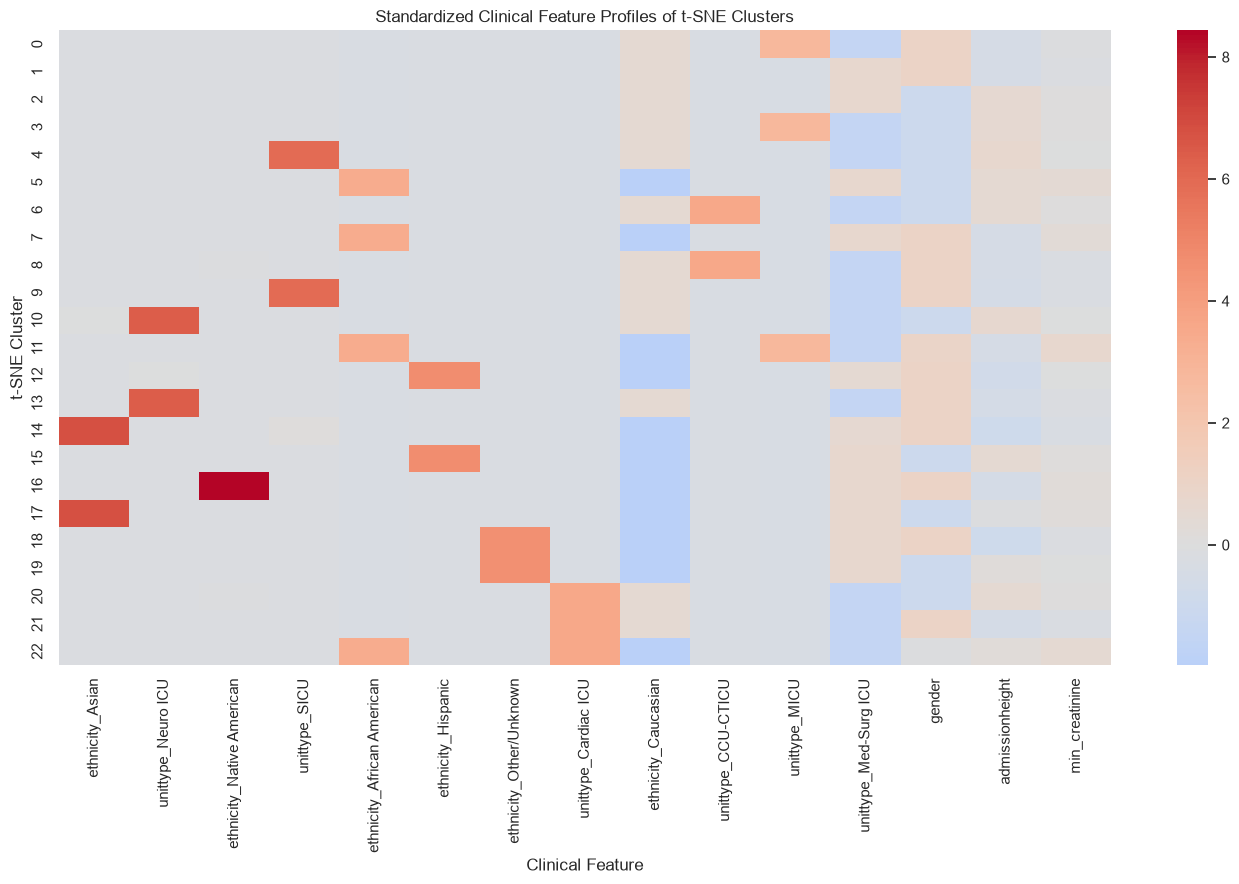

In [39]:
plt.figure(figsize=(14, 9))

# Show whether each important feature is relatively high or low
# within every t-SNE cluster
sns.heatmap(
    cluster_profiles[top_profile_features],
    cmap="coolwarm",
    center=0
)

plt.title(
    "Standardized Clinical Feature Profiles of t-SNE Clusters"
)

plt.xlabel("Clinical Feature")
plt.ylabel("t-SNE Cluster")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_clinical_feature_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Identify the Five Strongest Features in Each Cluster

In [40]:
# This list will store the five strongest characteristics
# for every discovered cluster
top_features = []

for cluster in cluster_profiles.index:

    # Get the average standardized feature profile for this cluster
    profile = cluster_profiles.loc[cluster]

    # Rank features by absolute distance from the cohort average.
    # Both strongly high and strongly low values are important.
    strongest_features = (
        profile
        .reindex(
            profile.abs()
            .sort_values(ascending=False)
            .index
        )
        .head(5)
    )

    # Store the selected features in a long-format table
    for feature, value in strongest_features.items():

        top_features.append({
            "cluster": cluster,
            "feature": feature,
            "standardized_mean": value
        })

top_features_df = pd.DataFrame(top_features)

top_features_df.round(3)

,cluster,feature,standardized_mean
0,0,unittype_MICU,2.798
1,0,unittype_Med-Surg ICU,-1.466
2,0,gender,1.015
3,0,ethnicity_Caucasian,0.506
4,0,admissionheight,-0.475
...,...,...,...
110,22,unittype_Cardiac ICU,3.571
111,22,ethnicity_African American,3.384
112,22,ethnicity_Caucasian,-1.977
113,22,unittype_Med-Surg ICU,-1.466


## Identify High-Risk and Low-Risk Clusters

### Rank Clusters by Hospital Mortality

In [41]:
# Keep the most important severity and mortality variables
mortality_ranking = (
    clinical_summary[
        [
            "cluster",
            "patients",
            "mean_apache_iva",
            "icu_mortality",
            "hospital_mortality"
        ]
    ]

    # Highest hospital mortality appears first
    .sort_values(
        "hospital_mortality",
        ascending=False
    )
)

mortality_ranking.round(2)

,cluster,patients,mean_apache_iva,icu_mortality,hospital_mortality
17,17,55,77.82,18.18,28.30
22,22,57,72.07,17.54,24.56
11,11,55,68.78,23.64,23.64
15,15,119,72.95,11.76,23.53
20,20,230,72.20,14.35,23.04
14,14,64,67.89,18.75,21.88
5,5,173,79.81,12.14,21.43
6,6,227,73.22,10.57,21.15
16,16,55,78.61,12.73,20.00
0,0,360,75.53,14.44,19.83


## Save Final Results

### Save t-SNE Cluster Assignments

In [42]:
# Save patient identifiers, t-SNE coordinates, and DBSCAN labels
tsne_results.to_csv(
    RESULTS_DIR / "tsne_dbscan_clusters.csv",
    index=False
)

print("Saved t-SNE DBSCAN cluster assignments.")

Saved t-SNE DBSCAN cluster assignments.


### Save Internal Evaluation Results

In [43]:
# Save the main internal clustering quality metrics
evaluation_summary.to_csv(
    RESULTS_DIR / "tsne_evaluation_metrics.csv",
    index=False
)

print("Saved internal evaluation metrics.")

Saved internal evaluation metrics.


### Save Clinical Outcome Summary

In [44]:
# Save one clinical summary row for each discovered cluster
clinical_summary.to_csv(
    RESULTS_DIR / "tsne_clinical_summary.csv",
    index=False
)

print("Saved clinical outcome summary.")

Saved clinical outcome summary.


### Save Clinical Outcome Summary

In [45]:
# Save one clinical summary row for each discovered cluster
clinical_summary.to_csv(
    RESULTS_DIR / "tsne_clinical_summary.csv",
    index=False
)

print("Saved clinical outcome summary.")

Saved clinical outcome summary.


### Save Cluster Feature Profiles

In [46]:
# Save the complete standardized feature profile of every cluster
cluster_profiles.to_csv(
    RESULTS_DIR / "tsne_cluster_feature_profiles.csv"
)

# Save the five strongest distinguishing features per cluster
top_features_df.to_csv(
    RESULTS_DIR / "tsne_top_cluster_features.csv",
    index=False
)

print("Saved clinical feature profiles.")

Saved clinical feature profiles.


### Save the DBSCAN Epsilon Comparison

In [47]:
# Save the small parameter comparison so the final epsilon choice
# remains documented and reproducible
eps_comparison.to_csv(
    RESULTS_DIR / "tsne_dbscan_epsilon_comparison.csv",
    index=False
)

print("Saved DBSCAN epsilon comparison.")

Saved DBSCAN epsilon comparison.


### Create the Replication Comparison Table

In [48]:
# Published t-SNE + DBSCAN values from Ju and Dubin
# are included only as replication benchmarks.
paper_comparison = pd.DataFrame({
    "metric": [
        "Number of clusters",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "our_replication": [
        n_clusters,
        silhouette,
        dbi,
        chi
    ],

    "ju_dubin_paper": [
        22,
        0.67,
        0.25,
        8576.69
    ]
})

paper_comparison.round(4)

,metric,our_replication,ju_dubin_paper
0,Number of clusters,23.0000,22.00
1,Silhouette Score,0.5605,0.67
2,Davies-Bouldin Index,0.3360,0.25
3,Calinski-Harabasz Index,4696.9648,8576.69


### Final t-SNE + DBSCAN Summary

In [49]:
print("t-SNE + DBSCAN Final Summary")
print("-" * 45)

print("Dataset")
print("Patients:", len(tsne_results))
print("Clustering features:", len(feature_cols))

print()
print("t-SNE Parameters")
print("Dimensions:", TSNE_COMPONENTS)
print("Perplexity:", TSNE_PERPLEXITY)
print("Metric: Euclidean")
print("Random state:", RANDOM_STATE)

print()
print("DBSCAN Parameters")
print("Epsilon:", EPS)
print("Min samples:", MIN_SAMPLES)

print()
print("Clustering Results")
print("Clusters:", n_clusters)
print("Outliers:", n_outliers)

print(
    "Outlier percentage:",
    round(outlier_percentage, 2),
    "%"
)

print()
print("Internal Evaluation")

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(dbi, 4)
)

print(
    "Calinski-Harabasz Index:",
    round(chi, 2)
)

print()
print("Clinical Survival Evaluation")

print(
    "Patients in survival analysis:",
    len(survival_data)
)

print(
    "ICU deaths:",
    int(survival_data["icu_mortality"].sum())
)

print(
    "Log-rank statistic:",
    round(logrank_result.test_statistic, 4)
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

t-SNE + DBSCAN Final Summary
---------------------------------------------
Dataset
Patients: 7648
Clustering features: 80

t-SNE Parameters
Dimensions: 2
Perplexity: 30
Metric: Euclidean
Random state: 42

DBSCAN Parameters
Epsilon: 4.0
Min samples: 50

Clustering Results
Clusters: 23
Outliers: 576
Outlier percentage: 7.53 %

Internal Evaluation
Silhouette Score: 0.5605
Davies-Bouldin Index: 0.336
Calinski-Harabasz Index: 4696.96

Clinical Survival Evaluation
Patients in survival analysis: 7072
ICU deaths: 908
Log-rank statistic: 22.4436
Log-rank p-value: 0.4336937225020905
